## Theory(common to both)

Both labs implement quadratic regression using PyTorch's nn.Module. Instead of a simple linear model, the forward pass computes:
ŷ = ax² + bx + c
where a, b, and c are learnable parameters initialized randomly via nn.Parameter.
Training pipeline:
The standard five-step loop is followed each epoch:forward pass, loss computation, zero gradients, backpropagation (loss.backward()), and optimizer step. torch.inference_mode() is used during evaluation to disable gradient tracking for efficiency.
Loss function — MAE (L1Loss): Measures the average absolute difference between predicted and actual values. It is less sensitive to outliers than MSE (L2 loss).
Optimizer — SGD (lr = 0.01): Stochastic Gradient Descent updates parameters in the direction that minimizes loss. The learning rate of 0.01 provides a moderate step size — slow enough to be stable, fast enough to converge within hundreds of epochs.
Data split: 80% training, 20% testing, preserving sequential order from the CSV.



In [1]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Check PyTorch version
torch.__version__

'2.12.0+cpu'

In [2]:
import pandas as pd
import torch

df = pd.read_csv(r'assignment-data.csv')
df.head(6)

,x,y
0,0.0,2.00
1,0.2,2.12
2,0.4,2.48
3,0.6,3.08
4,0.8,3.92
5,1.0,5.00


In [3]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([50, 1])
torch.Size([50, 1])


In [4]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [5]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

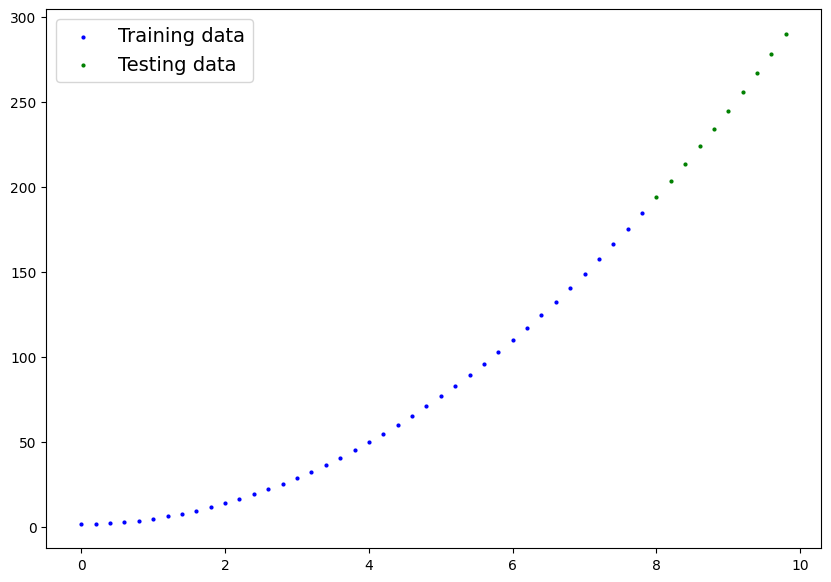

In [6]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

In [7]:

# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__() 
        self.a = nn.Parameter(torch.randn(1))
        self.b = nn.Parameter(torch.randn(1))
        self.c = nn.Parameter(torch.randn(1))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.a * x**2 + self.b * x + self.c

In [8]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True),
 Parameter containing:
 tensor([0.2345], requires_grad=True)]

In [9]:
print(model_0.a.dtype)
print(model_0.b.dtype)
print(model_0.c.dtype)

torch.float32
torch.float32
torch.float32


In [10]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[22.8131],
        [23.9298],
        [25.0733],
        [26.2438],
        [27.4413]])

In [11]:
print(model_0.a.dtype)
print(model_0.b.dtype)
print(model_0.c.dtype)

torch.float32
torch.float32
torch.float32


In [12]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[22.8131],
        [23.9298],
        [25.0733],
        [26.2438],
        [27.4413]])

In [13]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[22.8131],
        [23.9298],
        [25.0733],
        [26.2438],
        [27.4413],
        [28.6657],
        [29.9170],
        [31.1952],
        [32.5004],
        [33.8325]])


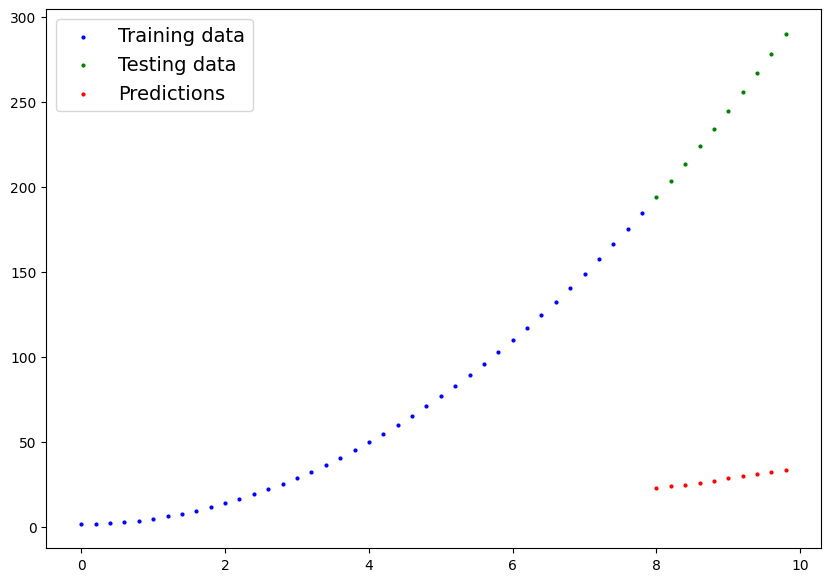

In [14]:
plot_predictions(predictions=y_preds)

In [15]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

In [16]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

In [21]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 600

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 3.503439426422119 | MAE Test Loss: 0.5804718136787415 
Epoch: 10 | MAE Train Loss: 3.6046462059020996 | MAE Test Loss: 0.872271716594696 
Epoch: 20 | MAE Train Loss: 3.235577344894409 | MAE Test Loss: 0.39808958768844604 
Epoch: 30 | MAE Train Loss: 3.5420031547546387 | MAE Test Loss: 0.6667816042900085 
Epoch: 40 | MAE Train Loss: 3.6432793140411377 | MAE Test Loss: 0.9880264401435852 
Epoch: 50 | MAE Train Loss: 3.3859703540802 | MAE Test Loss: 0.3780410885810852 
Epoch: 60 | MAE Train Loss: 3.568406581878662 | MAE Test Loss: 0.7236191034317017 
Epoch: 70 | MAE Train Loss: 3.0229580402374268 | MAE Test Loss: 1.1058533191680908 
Epoch: 80 | MAE Train Loss: 3.4172825813293457 | MAE Test Loss: 0.4002685546875 
Epoch: 90 | MAE Train Loss: 3.600076675415039 | MAE Test Loss: 0.7420791387557983 
Epoch: 100 | MAE Train Loss: 3.1478495597839355 | MAE Test Loss: 0.6650131344795227 
Epoch: 110 | MAE Train Loss: 3.466157913208008 | MAE Test Loss: 0.4095825254917145 
Ep

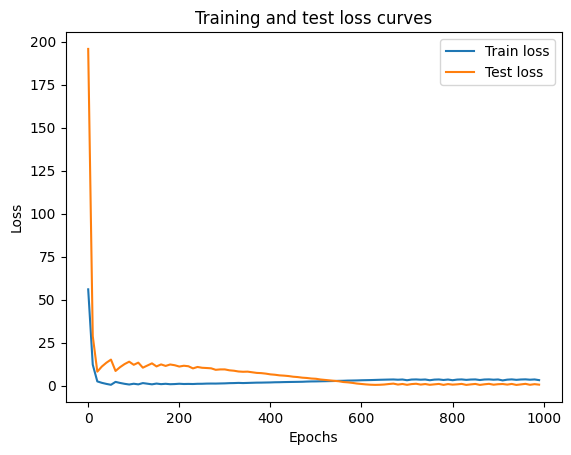

In [18]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [22]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: 0.7, bias: 0.3")

The model learned the following values for weights and bias:
OrderedDict({'a': tensor([2.7450]), 'b': tensor([0.6228]), 'c': tensor([1.6670])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


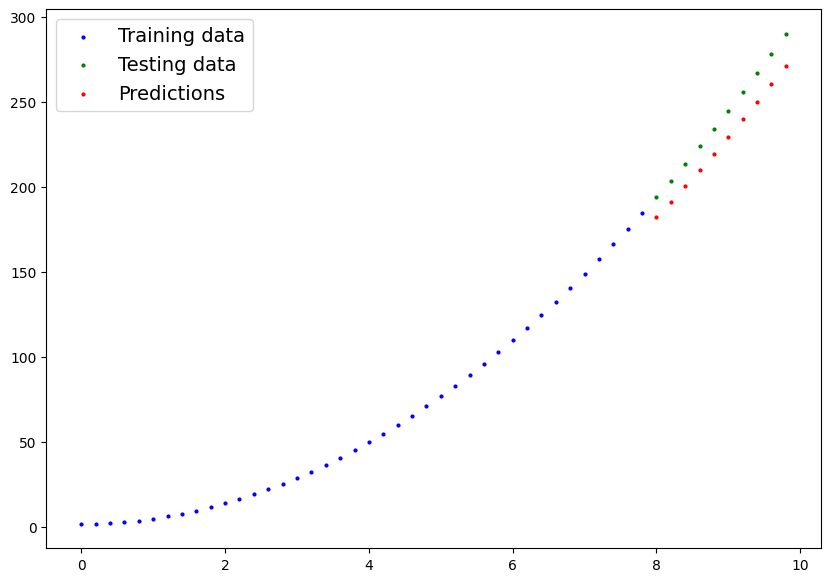

In [23]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

### Discussion and Conclusion


The model was trained on assignment-data.csv for 600 epochs using MAE loss and SGD (lr=0.01). Both train and test loss curves declined steadily, indicating successful learning without overfitting. Final predictions closely matched the test data, confirming good generalization.

The quadratic regression model successfully learned the underlying pattern from the data. 600 epochs with MAE loss and SGD proved sufficient for convergence and accurate prediction.